In [21]:
from tensorflow.keras.models import load_model
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="Budhadev/best-emotion-model",
    filename="best_emotion_model.keras"
)

In [22]:
model = load_model(model_path)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,053,399 (7.83 MB)

 Trainable params: 684,231 (2.61 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 1,368,464 (5.22 MB)

In [24]:
for layer in model.layers[:-3]:
    layer.trainable = False

In [25]:
label_map = {
    1: 5,  # Surprise → 5
    2: 2,  # Fear → 2
    3: 1,  # Disgust → 1
    4: 3,  # Happy → 3
    5: 4,  # Sad → 4
    6: 0,  # Angry → 0
    7: 6   # Neutral → 6
}

In [27]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/datasets/shuvoalok/raf-db-dataset/train_labels.csv")
test_df = pd.read_csv("/kaggle/input/datasets/shuvoalok/raf-db-dataset/train_labels.csv")

In [28]:
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

In [29]:
train_df['label'] = train_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

In [40]:
import os
img_path = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"
sample_file = os.path.join(img_path, train_df['image'].iloc[0])

print(f"Full path check: {sample_file}")
print(f"File exists: {os.path.exists(sample_file)}")


Full path check: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train/train_00001_aligned.jpg
File exists: False


In [46]:
import os

base_path = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"

print(os.listdir(base_path))

['7', '2', '5', '3', '1', '4', '6']


In [51]:
import os

print(os.listdir("/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET") )

['test', 'train']


In [53]:
print(os.listdir("/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train")[:10])

['7', '2', '5', '3', '1', '4', '6']


In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train",
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    subset="training",
    classes = ['6','3','2','4','5','1','7']
)

val_data = datagen.flow_from_directory(
    "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train",
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    classes = ['6','3','2','4','5','1','7']
)

Found 9819 images belonging to 7 classes.
Found 2452 images belonging to 7 classes.


In [79]:
print(train_data.class_indices)

{'6': 0, '3': 1, '2': 2, '4': 3, '5': 4, '1': 5, '7': 6}


In [59]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


307/307 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.5849 - loss: 1.1897 - val_accuracy: 0.6721 - val_loss: 0.9417
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.6412 - loss: 0.9944 - val_accuracy: 0.6688 - val_loss: 0.9333
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6411 - loss: 0.9748 - val_accuracy: 0.6741 - val_loss: 0.9264
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.6493 - loss: 0.9559 - val_accuracy: 0.6782 - val_loss: 0.9127
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.6502 - loss: 0.9526 - val_accuracy: 0.6807 - val_loss: 0.8984
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.6558 - loss: 0.9589 - val_accuracy: 0.6774 - val_loss: 0.9114
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.6506 - loss: 0.9523 - val_accuracy: 0.6725 - val_loss: 0.8981
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.6508 - loss: 0.9416 - val_accurac

In [60]:
for layer in model.layers:
    layer.trainable = True

In [61]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [62]:
from tensorflow.keras.callbacks import EarlyStopping

# Defining the callback
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience=10,
    restore_best_weights=True
)

In [63]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.6308 - loss: 1.0186 - val_accuracy: 0.6684 - val_loss: 0.9259
Epoch 2/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.6404 - loss: 1.0052 - val_accuracy: 0.6839 - val_loss: 0.8987
Epoch 3/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6544 - loss: 0.9775 - val_accuracy: 0.6945 - val_loss: 0.8818
Epoch 4/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.6577 - loss: 0.9442 - val_accuracy: 0.6913 - val_loss: 0.8647
Epoch 5/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.6504 - loss: 0.9641 - val_accuracy: 0.6888 - val_loss: 0.8573
Epoch 6/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.6608 - loss: 0.9346 - val_accuracy: 0.6994 - val_loss: 0.8712
Epoch 7/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6607 - loss: 0.9548 - val_accuracy: 0.7007 - val_loss: 0.8534
Epoch 8/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.6733 - loss: 0

In [65]:
test_data = datagen.flow_from_directory(
    "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test",
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
    classes = ['6','3','2','4','5','1','7']
)

Found 3068 images belonging to 7 classes.


In [66]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6899 - loss: 0.8637
Test Loss: 0.7120235562324524
Test Accuracy: 0.7454367876052856


In [80]:
print(test_data.class_indices)

{'6': 0, '3': 1, '2': 2, '4': 3, '5': 4, '1': 5, '7': 6}


In [67]:
import numpy as np

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step


In [81]:
target_names = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

       Angry       0.65      0.62      0.63       162
     Disgust       0.49      0.24      0.33       160
        Fear       0.64      0.31      0.42        74
       Happy       0.87      0.89      0.88      1185
         Sad       0.64      0.65      0.65       478
    Surprise       0.77      0.74      0.75       329
     Neutral       0.66      0.77      0.71       680

    accuracy                           0.75      3068
   macro avg       0.67      0.60      0.62      3068
weighted avg       0.74      0.75      0.74      3068



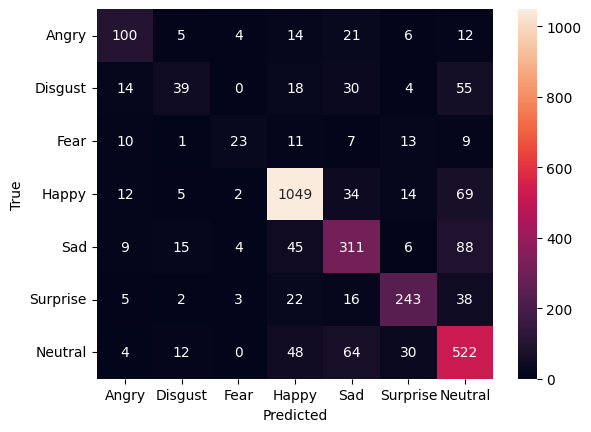

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [76]:
model.save("best_emotion_model_improved.keras")

In [85]:
import json

class_labels = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

with open("labels.json", "w") as f:
    json.dump(class_labels, f)